In [4]:
import os
import numpy as np  # NumPy polja [file:1]
from PIL import Image  # PIL Image.open, convert, show [web:1]

# pot do razpakiranega shapes/ direktorija
base_dir = "shapes"

classes = ["circles", "squares", "triangles"] 
image_paths = []
labels = []

for label_idx, cls in enumerate(classes):
    cls_dir = os.path.join(base_dir, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(cls_dir, fname))
            labels.append(label_idx)

labels = np.array(labels)
print(len(image_paths), "slik")


300 slik


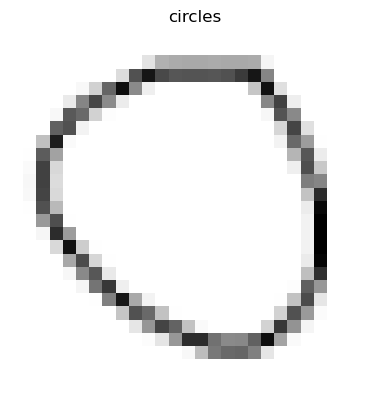

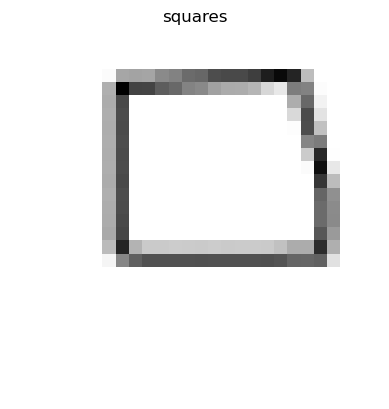

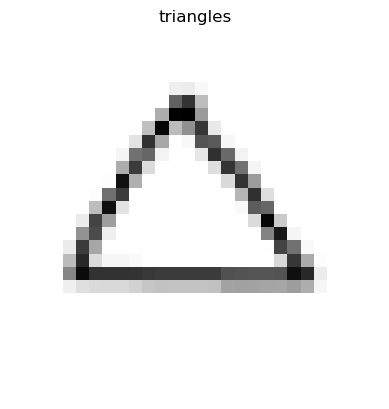

In [5]:
import matplotlib.pyplot as plt

for label_idx, cls in enumerate(classes):
    # prva pot s to oznako
    idx = labels.tolist().index(label_idx)
    img = Image.open(image_paths[idx]).convert("L")  # sivinska slika 'L' [web:1]
    plt.figure()
    plt.title(cls)
    plt.imshow(img, cmap="gray")
    plt.axis("off")


In [11]:
X_list = []
for path in image_paths:
    img = Image.open(path).convert("L")  # 'L' = grayscale [web:1]
    arr = np.array(img)                  # 2D NumPy polje [file:1]
    flat = arr.flatten()      
    X_list.append(flat)

X = np.stack(X_list, axis=0)  # (n_samples, n_features)
print(X.shape, labels.shape)


[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 232 189 184 183 183 184
 183 183 184 246 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 225 109  60 103 113 112 112 113 110  91  60 153 255 255 255 255
 255 255 255 255 255 255 255 255 255 249 216 126  53 157 241 255 255 255
 255 255 255 255 207  56 228 255 255 255 255 255 255 255 255 255 255 255
 237 153 100 158 239 255 255 255 255 255 255 255 255 255 255 154  96 240
 255 255 255 255 255 255 255 255 255 249 116 129 217 253 255 255 255 255
 255 255 255 255 255 255 255 248 112 156 255 255 255 255 255 255 255 255
 255 123 110 245 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 220  99 229 255 255 255 255 255 255 255 202  66 250 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 245 129 17

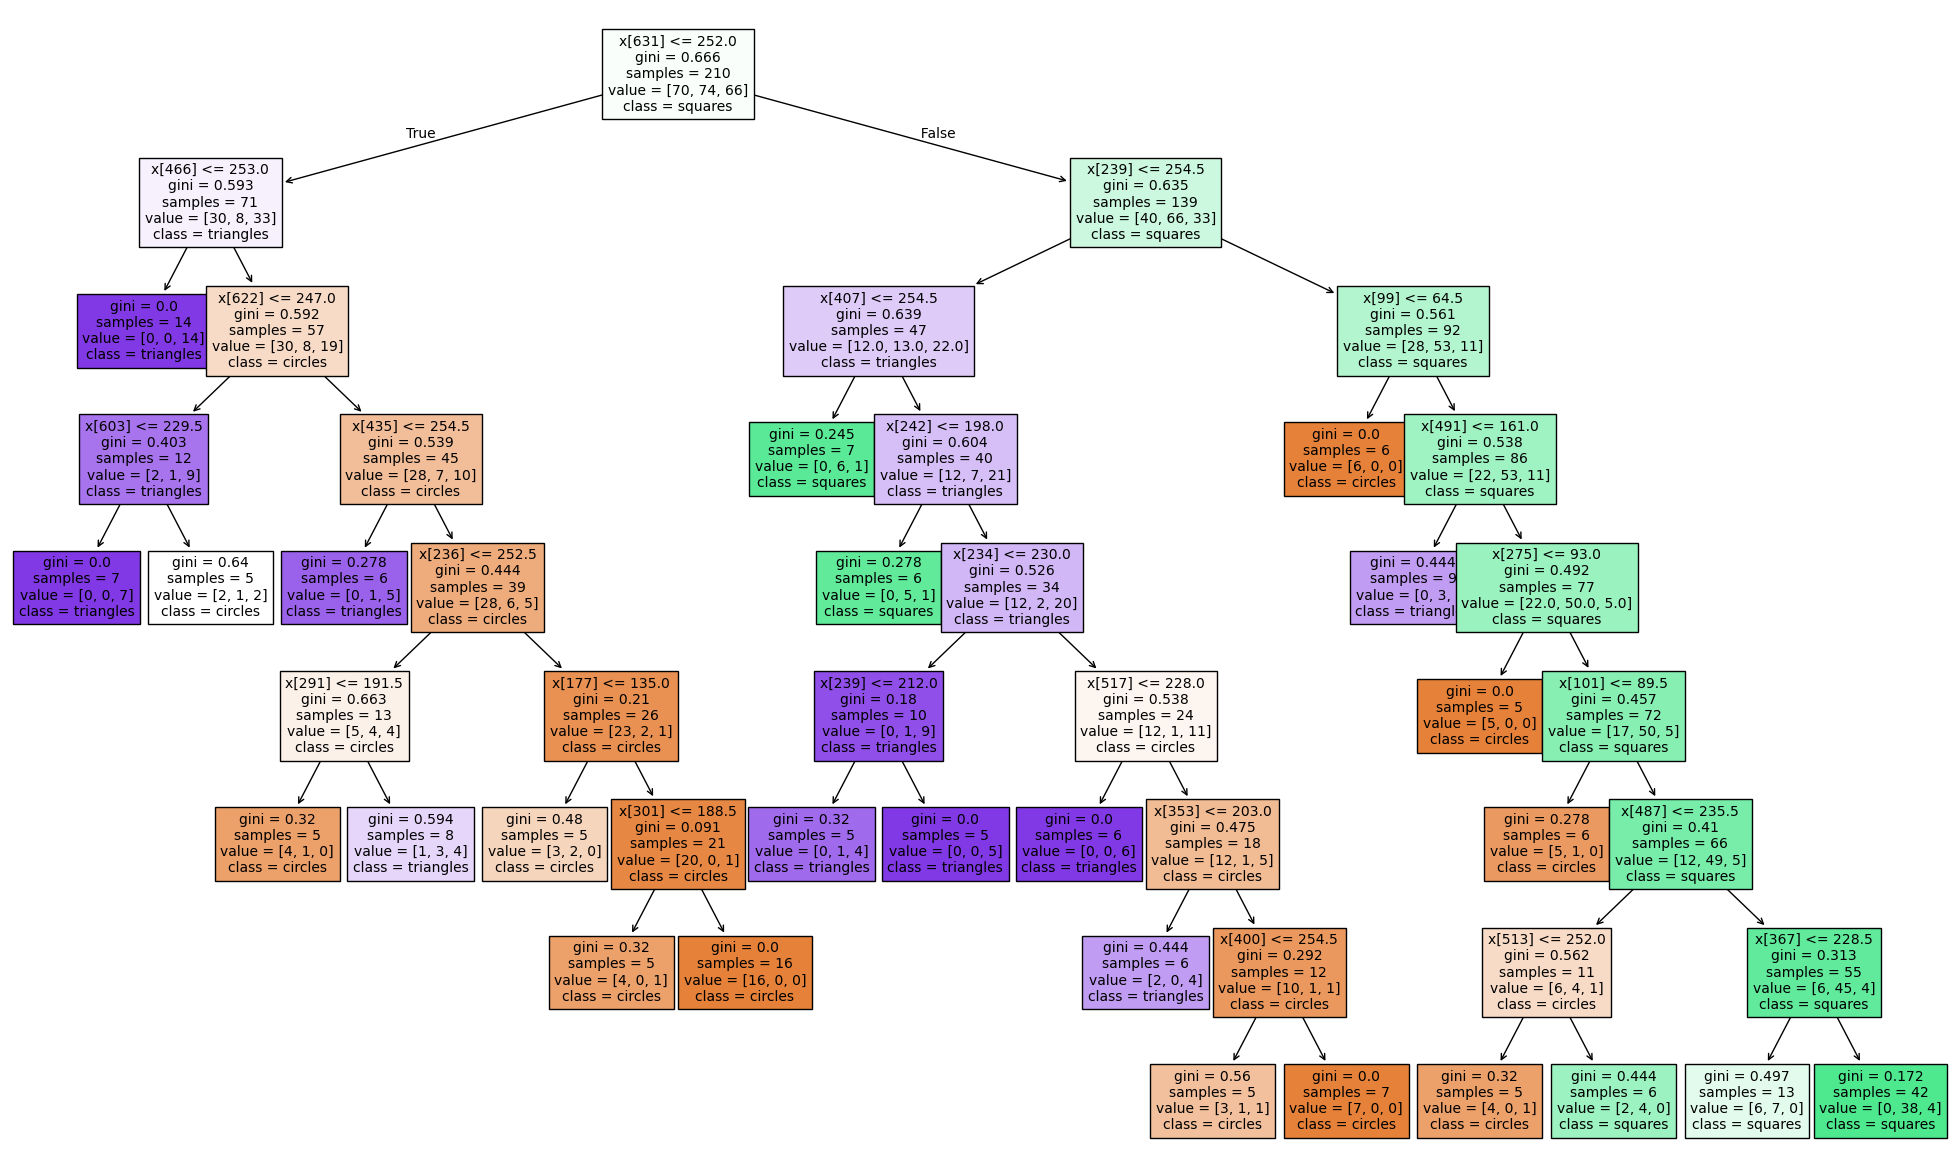

Decision Tree – accuracy: 0.4666666666666667
Decision Tree – weighted F1: 0.4650873168219486
Decision Tree – weighted precision: 0.47707911277336246
Decision Tree – weighted recall: 0.4666666666666667


In [12]:
from sklearn.model_selection import train_test_split  # [web:14]
from sklearn.tree import DecisionTreeClassifier, plot_tree  # [web:9]
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score  # [web:14]
import matplotlib.pyplot as plt

# delitev na učno in testno množico
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=4321, shuffle=True  # parametri funkcije [web:14]
)

# model – odločitveno drevo
dt = DecisionTreeClassifier(
    random_state=1234,
    max_depth=8,
    min_samples_split=10,   # minimalno vzorcev za delitev
    min_samples_leaf=5      # minimalno vzorcev v listu
)
dt.fit(X_train, y_train)

plt.figure(figsize=(25, 15))
plot_tree(dt, filled=True, class_names=classes, fontsize=10)
plt.savefig("drevo.png", dpi=300, bbox_inches='tight') 
plt.show()


# napovedi in metrike
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average="weighted")        # utežena F1 [web:14]
prec_dt = precision_score(y_test, y_pred_dt, average="weighted")  # utežena preciznost [web:14]
rec_dt = recall_score(y_test, y_pred_dt, average="weighted")      # utežen priklic [web:14]

print("Decision Tree – accuracy:", acc_dt)
print("Decision Tree – weighted F1:", f1_dt)
print("Decision Tree – weighted precision:", prec_dt)
print("Decision Tree – weighted recall:", rec_dt)


In [9]:
from sklearn.neighbors import KNeighborsClassifier  # [web:10]

knn = KNeighborsClassifier(n_neighbors=3)  # osnovni parameter n_neighbors [web:10]
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")
prec_knn = precision_score(y_test, y_pred_knn, average="weighted")
rec_knn = recall_score(y_test, y_pred_knn, average="weighted")

print("KNN – accuracy:", acc_knn)
print("KNN – weighted F1:", f1_knn)
print("KNN – weighted precision:", prec_knn)
print("KNN – weighted recall:", rec_knn)


KNN – accuracy: 0.5333333333333333
KNN – weighted F1: 0.5112277706643904
KNN – weighted precision: 0.6433423667570008
KNN – weighted recall: 0.5333333333333333


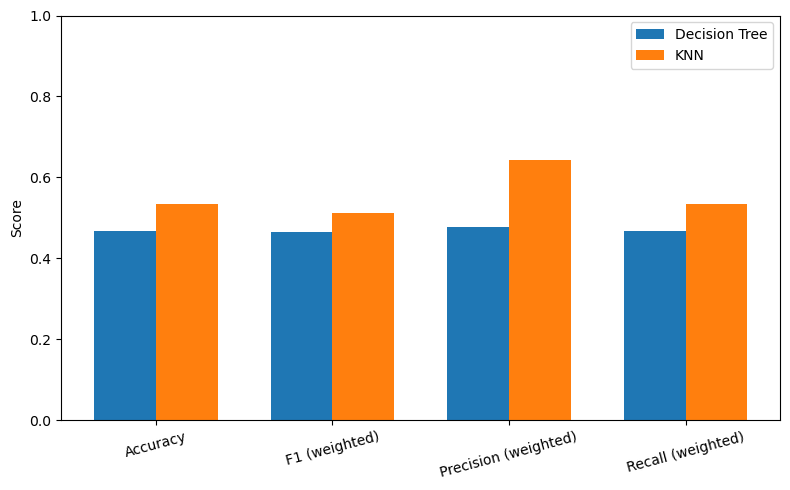

In [10]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "F1 (weighted)", "Precision (weighted)", "Recall (weighted)"]
dt_scores = [acc_dt, f1_dt, prec_dt, rec_dt]
knn_scores = [acc_knn, f1_knn, prec_knn, rec_knn]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, dt_scores, width, label="Decision Tree")
plt.bar(x + width/2, knn_scores, width, label="KNN")
plt.xticks(x, metrics, rotation=15)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()
